# Sensors Trail Digital Twin Reproduction

This notebook is intentionally paper-focused. It reproduces the Sensors 2026 trail digital twin pipeline on local repository data and keeps extensions out of this file.

Cohorts evaluated:

- `hardTrailRun`: hard/race-like TrailRuns.
- `top10HardTrailByHRR`: the 10 hard TrailRuns with the highest average HR reserve ratio.
- `selectedDateRaces`: one best usable activity per editable date in `SELECTED_RACE_DATE_STRINGS`.

Training load is computed from all activities. Weather uses only first-party Strava fields or reviewed caches; activity descriptions and Enduraw-derived text are not used.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from services import trail_performance_model as tpm

DATA_DIR = PROJECT_ROOT / "data"
TIMESERIES_DIR = DATA_DIR / "timeseries"
METRICS_TS_DIR = DATA_DIR / "metrics_ts"
RAW_STRAVA_DIR = DATA_DIR / "raw" / "strava"
SEGMENT_KM = 1.0

SELECTED_RACE_DATE_STRINGS = [
    "2025-10-18",
    "2026-04-12",
    "2025-08-06",
    "2025-09-28",
    "2025-06-23",
    "2025-07-27",
    "2025-07-24",
    "2025-08-01",
    "2024-08-18",
    "2025-11-01",
    "2025-04-27",
    "2025-07-12",
    "2026-02-22",
    "2026-04-18",
    "2024-07-28",
    "2025-08-03",
    "2025-06-29",
    "2025-08-23",
]

#TODO : what are those weights ?


CTL_WEIGHT = 0.05
TSB_WEIGHT = 0.10
CTL_FACTOR_MIN = 0.90
CTL_FACTOR_MAX = 1.08

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (9, 5)

PAPER_ALPHA_GRID = np.round(np.arange(0.40, 1.0001, 0.02), 2)
PAPER_MU_GRID = np.round(np.arange(-0.50, 0.0001, 0.02), 2)


/home/pmarrec/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load Tables and Physiology

The paper uses a laboratory uphill VT2. This repository does not include that measurement, so the paper reproduction uses the existing `Threshold 30` flat-speed proxy and labels the limitation explicitly.

In [2]:
activities = pd.read_csv(DATA_DIR / "activities.csv", dtype={"activityId": str})
activity_metrics = pd.read_csv(DATA_DIR / "activities_metrics.csv", dtype={"activityId": str})
athletes = pd.read_csv(DATA_DIR / "athlete.csv")
thresholds = pd.read_csv(DATA_DIR / "thresholds.csv")
daily_metrics = pd.read_csv(DATA_DIR / "daily_metrics.csv")

metric_cols = [
    "activityId",
    "category",
    "distanceEqKm",
    "trimp",
    "hrSpeedShift",
    "hrZone_z1_upper",
    "hrZone_z2_upper",
    "hrZone_z3_upper",
    "hrZone_z4_upper",
]
metric_cols = [col for col in metric_cols if col in activity_metrics.columns]
activity_df = activities.merge(activity_metrics[metric_cols], on="activityId", how="left")

athlete = athletes.iloc[0]
HR_REST = float(athlete.get("hrRest", 60.0))
HR_MAX = float(athlete.get("hrMax", 190.0))
threshold_30 = thresholds[thresholds["name"].astype(str).eq("Threshold 30")]
if not threshold_30.empty:
    threshold_row = threshold_30.iloc[0]
    V_VT2_KMH = float(
        np.nanmean([
            pd.to_numeric(threshold_row.get("paceFlatKmhMin"), errors="coerce"),
            pd.to_numeric(threshold_row.get("paceFlatKmhMax"), errors="coerce"),
        ])
    )
else:
    V_VT2_KMH = 15.0

activity_df = tpm.add_hr_reserve(activity_df, hr_rest=HR_REST, hr_max=HR_MAX)
activity_df["actualTimeSec"] = pd.to_numeric(activity_df["movingSec"], errors="coerce")
activity_df["actualTimeSec"] = activity_df["actualTimeSec"].where(
    activity_df["actualTimeSec"] > 0,
    pd.to_numeric(activity_df["elapsedSec"], errors="coerce"),
)
activity_df["startDate"] = pd.to_datetime(activity_df["startTime"], errors="coerce").dt.date
activity_df["category"] = activity_df["category"].astype(str)

print(f"Activities loaded: {len(activity_df)}")
print(f"HR rest/max: {HR_REST:.0f}/{HR_MAX:.0f} bpm")
print(f"VT2 proxy speed from Threshold 30: {V_VT2_KMH:.2f} km/h")
display(activity_df["category"].fillna("missing").value_counts().rename("count").to_frame())


Activities loaded: 711
HR rest/max: 55/205 bpm
VT2 proxy speed from Threshold 30: 15.50 km/h


,count
category,
RIDE,240
RUN,173
OTHER,165
TRAIL_RUN,80
HIKE,32
BACKCOUNTRY_SKI,21


## Training Load and REDI

CTL/ATL/TSB are computed from all daily activity TRIMP with the paper-style 42 day and 7 day time constants. REDI is added as a comparison readiness signal, also from all activities.

In [3]:
def rename_load_features(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    return df.rename(
        columns={
            "load": f"{prefix}Load",
            "ctl": f"{prefix}Ctl",
            "atl": f"{prefix}Atl",
            "tsb": f"{prefix}Tsb",
        }
    )

trimp_load = rename_load_features(tpm.compute_ctl_atl_tsb(daily_metrics, load_col="trimp"), "trimp")
distance_eq_load = rename_load_features(
    tpm.compute_ctl_atl_tsb(daily_metrics, load_col="distanceEqKm"),
    "distanceEq",
)
vertical_load = rename_load_features(tpm.compute_ctl_atl_tsb(daily_metrics, load_col="ascentM"), "vertical")
redi_load = tpm.compute_redi_load_features(daily_metrics, load_col="trimp", prefix="trimp")

for feature_df in [trimp_load, distance_eq_load, vertical_load, redi_load]:
    cols = [col for col in feature_df.columns if col != "date"]
    activity_df = tpm.attach_previous_daily_features(activity_df, feature_df, feature_cols=cols)

activity_df = activity_df.rename(columns={"trimpCtl": "ctl", "trimpAtl": "atl", "trimpTsb": "tsb"})

weather_records = []
for activity_id in activity_df["activityId"].astype(str):
    raw_path = RAW_STRAVA_DIR / f"{activity_id}.json"
    parsed = {"activityId": activity_id, "temperatureC": np.nan, "weatherSource": ""}
    if raw_path.exists():
        try:
            detail = json.loads(raw_path.read_text())
            temperature = pd.to_numeric(detail.get("average_temp"), errors="coerce")
            if pd.notna(temperature):
                parsed["temperatureC"] = float(temperature)
                parsed["weatherSource"] = "strava_average_temp"
        except Exception:
            pass
    weather_records.append(parsed)
weather_df = pd.DataFrame(weather_records)
activity_df = activity_df.merge(weather_df, on="activityId", how="left")

print(f"Training-load daily rows: {len(trimp_load)}")
print(f"Activities with Strava average_temp: {weather_df['temperatureC'].notna().sum()}")


Training-load daily rows: 774
Activities with Strava average_temp: 40


## Segment Extraction

The paper uses kilometre segments. The notebook rebuilds 1 km segments from local streams with smoothed elevation, grade, D+/D-, altitude, HR reserve, speed-equivalent, terrain family, and GPS technicality.

In [4]:
def load_processed_timeseries(activity_id: str) -> pd.DataFrame:
    raw_path = TIMESERIES_DIR / f"{activity_id}.csv"
    if raw_path.exists():
        raw_df = pd.read_csv(raw_path)
        processed = tpm.prepare_raw_timeseries_for_segments(raw_df)
        if not processed.empty and "cumulated_distance" in processed.columns:
            if "speed_km_h" in processed.columns and "grade_ma_10" in processed.columns:
                processed["speed_eq_km_h"] = processed["speed_km_h"] * processed["grade_ma_10"].map(tpm.gap_factor)
            return processed

    metrics_path = METRICS_TS_DIR / f"{activity_id}.csv"
    if metrics_path.exists():
        return pd.read_csv(metrics_path)
    return pd.DataFrame()

segment_candidates = activity_df[
    activity_df["category"].astype(str).str.upper().isin(["TRAIL_RUN", "RUN"])
    & activity_df["hasTimeseries"].astype(str).str.lower().isin(["true", "1", "yes"])
].copy()

segments_by_activity: dict[str, pd.DataFrame] = {}
segment_frames = []
qc_rows = []
for _, row in segment_candidates.iterrows():
    activity_id = str(row["activityId"])
    ts_df = load_processed_timeseries(activity_id)
    segments = tpm.segment_timeseries(ts_df, segment_km=SEGMENT_KM, hr_rest=HR_REST, hr_max=HR_MAX)
    usable = not segments.empty and segments["distanceKm"].sum() > 0 and segments["actualTimeSec"].sum() > 0
    qc_rows.append(
        {
            "activityId": activity_id,
            "name": row.get("name"),
            "category": row.get("category"),
            "usableSegments": usable,
            "segmentCount": len(segments),
            "segmentDistanceKm": float(segments["distanceKm"].sum()) if usable else 0.0,
            "segmentTimeSec": float(segments["actualTimeSec"].sum()) if usable else 0.0,
        }
    )
    if usable:
        segments = segments.copy()
        segments["activityId"] = activity_id
        if "terrainFamily" not in segments.columns:
            segments["terrainFamily"] = segments["avgGrade"].map(tpm.terrain_family)
        else:
            segments["terrainFamily"] = segments["terrainFamily"].fillna(segments["avgGrade"].map(tpm.terrain_family))
        segments_by_activity[activity_id] = segments
        segment_frames.append(segments)

qc_df = pd.DataFrame(qc_rows)
all_segments_df = pd.concat(segment_frames, ignore_index=True) if segment_frames else pd.DataFrame()
segment_summary = (
    all_segments_df.groupby("activityId")
    .agg(
        technicalityGps=("technicalityGps", "mean"),
        meanAltitudeM=("meanAltitudeM", "mean"),
        segmentDistanceKm=("distanceKm", "sum"),
        segmentActualTimeSec=("actualTimeSec", "sum"),
        meanSegmentHrReserve=("meanHrReserve", "mean"),
        meanSpeedEqKmh=("meanSpeedEqKmh", "mean"),
    )
    .reset_index()
    if not all_segments_df.empty
    else pd.DataFrame(columns=["activityId"])
)
activity_df = activity_df.merge(segment_summary, on="activityId", how="left")
activity_df["usableSegmentActivity"] = activity_df["activityId"].astype(str).isin(segments_by_activity)
activity_df["usableTrailRun"] = activity_df["category"].astype(str).str.upper().eq("TRAIL_RUN") & activity_df["usableSegmentActivity"]
activity_df["hardTrailRun"] = tpm.hard_trailrun_mask(activity_df) & activity_df["usableSegmentActivity"]

print(f"Usable run/trail activities with segments: {len(segments_by_activity)}")
print(f"Usable TrailRuns: {int(activity_df['usableTrailRun'].sum())}")
print(f"Hard race-like TrailRuns: {int(activity_df['hardTrailRun'].sum())}")
display(qc_df.head(10))


/home/pmarrec/Projet_Perso/RunningManager/services/trail_performance_model.py:206: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)


Usable run/trail activities with segments: 248
Usable TrailRuns: 79
Hard race-like TrailRuns: 45


,activityId,name,category,usableSegments,segmentCount,segmentDistanceKm,segmentTimeSec
0,11277623453,Sortie recup,RUN,True,7,6.055611,1934.0
1,11297452009,Sortie tranquille a Vincennes,RUN,True,9,8.948131,2944.0
2,11302257945,Afternoon Run,RUN,False,0,0.000000,0.0
3,11345784109,Sortie en Terres lyonnaises,RUN,True,9,8.508865,2829.0
4,11387382620,Sortie trail très dense,TRAIL_RUN,True,6,5.067856,3151.0
5,11394769089,La recup,RUN,True,5,4.664070,1628.0
6,11450736281,Night Run,RUN,True,10,9.845686,3463.0
7,11462693706,Sortie fonda,RUN,True,11,10.149817,3220.0
8,11531867370,Je test les nouvelles chaussures,RUN,True,8,8.001478,2785.0
9,11562663514,Lunch Run,RUN,True,10,9.915052,3264.0


## Cohorts

`SELECTED_RACE_DATE_STRINGS` is the editable date-list cohort. The selection rule prefers `TRAIL_RUN`, then `RUN`, then largest `distanceKm + 0.01 * ascentM`.

In [5]:
def add_readiness_factors(df: pd.DataFrame, value_col: str, balance_col: str, output_col: str) -> pd.DataFrame:
    result = df.copy()
    reference = float(pd.to_numeric(result[value_col], errors="coerce").median())
    if not np.isfinite(reference) or reference <= 0:
        reference = 1.0
    result[output_col] = result.apply(
        lambda row: tpm.ctl_readiness_factor(
            row.get(value_col, np.nan),
            row.get(balance_col, 0.0),
            ctl_reference=reference,
            ctl_weight=CTL_WEIGHT,
            tsb_weight=TSB_WEIGHT,
            min_factor=CTL_FACTOR_MIN,
            max_factor=CTL_FACTOR_MAX,
        ),
        axis=1,
    )
    return result

activity_df = add_readiness_factors(activity_df, "ctl", "tsb", "ctlReadinessFactor")
activity_df = add_readiness_factors(
    activity_df,
    "trimpRediSlow",
    "trimpRediBalance",
    "rediReadinessFactor",
)

hard_activity_df = activity_df[activity_df["hardTrailRun"]].copy()
top10_ids = tpm.top_hrr_hard_trailrun_ids(activity_df, n=10)
top10_activity_df = activity_df[activity_df["activityId"].astype(str).isin(top10_ids)].copy()
selected_activity_df = tpm.select_best_activity_by_dates(activity_df, SELECTED_RACE_DATE_STRINGS)
selected_activity_df = selected_activity_df[
    selected_activity_df["activityId"].astype(str).isin(segments_by_activity)
].copy()

cohorts = {
    "hardTrailRun": hard_activity_df,
    "top10HardTrailByHRR": top10_activity_df,
    "selectedDateRaces": selected_activity_df,
}
cohort_counts = pd.DataFrame(
    [
        {
            "cohort": name,
            "activities": len(df),
            "distanceKm": pd.to_numeric(df.get("distanceKm"), errors="coerce").sum(),
            "ascentM": pd.to_numeric(df.get("ascentM"), errors="coerce").sum(),
            "hrReserveRatio": pd.to_numeric(df.get("hrReserveRatio"), errors="coerce").mean(),
        }
        for name, df in cohorts.items()
    ]
)
display(cohort_counts)
display(selected_activity_df[["requestedDate", "activityId", "name", "category", "distanceKm", "ascentM", "hrReserveRatio"]].sort_values("requestedDate"))


,cohort,activities,distanceKm,ascentM,hrReserveRatio
0,hardTrailRun,45,797.3853,44873.0,0.657185
1,top10HardTrailByHRR,10,146.5193,7665.0,0.791067
2,selectedDateRaces,18,407.0342,20084.0,0.747630


,requestedDate,activityId,name,category,distanceKm,ascentM,hrReserveRatio
86,2024-07-28,12000338229,TRAIL Locunolois 2024,RUN,25.0739,668.0,0.748000
96,2024-08-18,12177245147,La Montée du Menez Hom 2024,RUN,23.8238,529.0,0.801333
236,2025-04-27,14300194854,Trail des 3 pucelles 2025,TRAIL_RUN,23.5397,1174.0,0.762667
287,2025-06-23,14893241615,Sortie seuil,TRAIL_RUN,6.8750,407.0,0.760000
292,2025-06-29,14953411411,Moyen duc 2025,TRAIL_RUN,47.1356,3054.0,0.617333
303,2025-07-12,15087396899,Trail de côte rouge 2025 (Passerelle de Montey...,TRAIL_RUN,26.8970,1266.0,0.760000
314,2025-07-24,15224440864,J’allais pas partir sans chercher les PRs,TRAIL_RUN,14.8051,892.0,0.747333
316,2025-07-27,15250276952,Trail locunolois 2025 : mission accomplie,TRAIL_RUN,24.5830,659.0,0.756667
319,2025-08-01,15310799882,Ça cherche le d+ et ça descend fooort,RUN,15.6164,469.0,0.718000
321,2025-08-03,15329205386,Trail des deux moulins,TRAIL_RUN,25.8671,466.0,0.582000


## Paper-Style Stage Evaluation

For paper comparability, calibration is race-level: segment predictions are summed to race finish time before computing the grid-search objective. Segment-level fitting appears only as a diagnostic table.

In [6]:
PAPER_ALPHA_GRID = np.round(np.arange(0.40, 1.0001, 0.02), 2)
PAPER_MU_GRID = np.round(np.arange(-0.50, 0.0001, 0.02), 2)
PAPER_REFERENCE = pd.DataFrame(
    [
        {"stage": "Stage 1 distance-only", "paperR2": 0.679, "paperMaeMin": 28.3, "paperMapePct": 17.6},
        {"stage": "Stage 2 GAP + altitude", "paperR2": 0.871, "paperMaeMin": 21.1, "paperMapePct": 14.0},
        {"stage": "Stage 3 calibrated", "paperR2": 0.905, "paperMaeMin": 14.6, "paperMapePct": 8.7},
        {"stage": "LOO Stage 3", "paperR2": 0.864, "paperMaeMin": 18.2, "paperMapePct": 11.1},
    ]
)


def metrics_row(cohort: str, stage: str, actual, predicted) -> dict[str, object]:
    metrics = tpm.regression_metrics(actual, predicted)
    return {
        "cohort": cohort,
        "stage": stage,
        "r2": metrics["r2"],
        "maeMin": metrics["maeSec"] / 60.0,
        "mapePct": metrics["mapePct"],
        "biasMin": metrics["biasSec"] / 60.0,
    }




def prediction_frame(
    cohort_name: str,
    model_name: str,
    cohort_df: pd.DataFrame,
    actual: pd.Series,
    predicted: pd.Series,
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "activityId": actual.index.astype(str),
            "actualTimeSec": actual.to_numpy(dtype=float),
            "predictedTimeSec": predicted.reindex(actual.index).to_numpy(dtype=float),
        }
    )
    meta_cols = [
        col
        for col in ["activityId", "startDate", "name", "distanceKm", "ascentM", "hrReserveRatio"]
        if col in cohort_df.columns
    ]
    frame = frame.merge(cohort_df[meta_cols].astype({"activityId": str}), on="activityId", how="left")
    frame["cohort"] = cohort_name
    frame["model"] = model_name
    frame["actualMin"] = frame["actualTimeSec"] / 60.0
    frame["predictedMin"] = frame["predictedTimeSec"] / 60.0
    frame["errorMin"] = (frame["predictedTimeSec"] - frame["actualTimeSec"]) / 60.0
    return frame


def cohort_inputs(cohort_df: pd.DataFrame):
    ids = cohort_df["activityId"].astype(str).tolist()
    segments = {activity_id: segments_by_activity[activity_id] for activity_id in ids}
    observed = cohort_df.set_index("activityId").loc[ids, "actualTimeSec"].astype(float)
    ctl_factors = cohort_df.set_index("activityId").loc[ids, "ctlReadinessFactor"].astype(float).to_dict()
    redi_factors = cohort_df.set_index("activityId").loc[ids, "rediReadinessFactor"].astype(float).to_dict()
    return ids, segments, observed, ctl_factors, redi_factors


paper_rows = []
parameter_rows = []
loo_frames = []
mu_curve_frames = []
segment_diagnostic_rows = []
stage3_prediction_frames = []
segment_prediction_frames = []
grid_by_cohort: dict[str, pd.DataFrame] = {}

for cohort_name, cohort_df in cohorts.items():
    ids, segments, actual, ctl_factors, redi_factors = cohort_inputs(cohort_df)
    if not ids:
        continue
    observed = actual.to_dict()
    flat_speed = cohort_df["distanceKm"].sum() / (actual.sum() / 3600.0)
    pred_stage1 = cohort_df.set_index("activityId").loc[ids, "distanceKm"] / flat_speed * 3600.0
    paper_rows.append(metrics_row(cohort_name, "Stage 1 distance-only", actual, pred_stage1))

    pred_stage2 = tpm.predict_many(segments, v_vt2_kmh=V_VT2_KMH, alpha=1.0, mu=0.0).reindex(ids)
    pred_stage2_ctl = tpm.predict_many(
        segments,
        v_vt2_kmh=V_VT2_KMH,
        alpha=1.0,
        mu=0.0,
        ctl_factors=ctl_factors,
    ).reindex(ids)
    pred_stage2_redi = tpm.predict_many(
        segments,
        v_vt2_kmh=V_VT2_KMH,
        alpha=1.0,
        mu=0.0,
        ctl_factors=redi_factors,
    ).reindex(ids)
    paper_rows.append(metrics_row(cohort_name, "Stage 2 GAP + altitude", actual, pred_stage2))
    paper_rows.append(metrics_row(cohort_name, "Stage 2 GAP + altitude + CTL", actual, pred_stage2_ctl))
    paper_rows.append(metrics_row(cohort_name, "Stage 2 GAP + altitude + REDI", actual, pred_stage2_redi))

    best_ctl, grid_ctl = tpm.grid_search_model(
        segments,
        observed,
        v_vt2_kmh=V_VT2_KMH,
        alpha_grid=PAPER_ALPHA_GRID,
        mu_grid=PAPER_MU_GRID,
        fatigue_model="linear",
        ctl_factors=ctl_factors,
    )
    pred_stage3_ctl = tpm.predict_many(
        segments,
        v_vt2_kmh=V_VT2_KMH,
        alpha=best_ctl["alpha"],
        mu=best_ctl["mu"],
        fatigue_model="linear",
        ctl_factors=ctl_factors,
    ).reindex(ids)
    paper_rows.append(metrics_row(cohort_name, "Stage 3 calibrated CTL", actual, pred_stage3_ctl))
    stage3_prediction_frames.append(
        prediction_frame(cohort_name, "Stage 3 CTL linear", cohort_df, actual, pred_stage3_ctl)
    )
    parameter_rows.append({"cohort": cohort_name, "model": "CTL linear", **best_ctl})
    grid_ctl["cohort"] = cohort_name
    grid_by_cohort[cohort_name] = grid_ctl

    best_redi, _grid_redi = tpm.grid_search_model(
        segments,
        observed,
        v_vt2_kmh=V_VT2_KMH,
        alpha_grid=PAPER_ALPHA_GRID,
        mu_grid=PAPER_MU_GRID,
        fatigue_model="linear",
        ctl_factors=redi_factors,
    )
    pred_stage3_redi = tpm.predict_many(
        segments,
        v_vt2_kmh=V_VT2_KMH,
        alpha=best_redi["alpha"],
        mu=best_redi["mu"],
        fatigue_model="linear",
        ctl_factors=redi_factors,
    ).reindex(ids)
    paper_rows.append(metrics_row(cohort_name, "Stage 3 calibrated REDI", actual, pred_stage3_redi))
    stage3_prediction_frames.append(
        prediction_frame(cohort_name, "Stage 3 REDI linear", cohort_df, actual, pred_stage3_redi)
    )
    parameter_rows.append({"cohort": cohort_name, "model": "REDI linear", **best_redi})

    best_exp, _grid_exp = tpm.grid_search_model(
        segments,
        observed,
        v_vt2_kmh=V_VT2_KMH,
        alpha_grid=PAPER_ALPHA_GRID,
        mu_grid=PAPER_MU_GRID,
        fatigue_model="exponential",
        ctl_factors=ctl_factors,
    )
    pred_stage3_exp = tpm.predict_many(
        segments,
        v_vt2_kmh=V_VT2_KMH,
        alpha=best_exp["alpha"],
        mu=best_exp["mu"],
        fatigue_model="exponential",
        ctl_factors=ctl_factors,
    ).reindex(ids)
    paper_rows.append(metrics_row(cohort_name, "Stage 3 exponential CTL", actual, pred_stage3_exp))
    stage3_prediction_frames.append(
        prediction_frame(cohort_name, "Stage 3 CTL exponential", cohort_df, actual, pred_stage3_exp)
    )
    parameter_rows.append({"cohort": cohort_name, "model": "CTL exponential", **best_exp})

    if len(ids) > 2:
        loo = tpm.leave_one_out_grid_search(
            segments,
            observed,
            v_vt2_kmh=V_VT2_KMH,
            alpha_grid=PAPER_ALPHA_GRID,
            mu_grid=PAPER_MU_GRID,
            fatigue_model="linear",
            ctl_factors=ctl_factors,
        )
        loo["cohort"] = cohort_name
        loo_frames.append(loo)
        paper_rows.append(metrics_row(cohort_name, "LOO Stage 3 CTL", loo["actualTimeSec"], loo["predictedTimeSec"]))

    fixed_alpha = best_ctl["alpha"]
    curve = grid_ctl[grid_ctl["alpha"].eq(fixed_alpha)].copy()
    curve["cohort"] = cohort_name
    curve["fixedAlpha"] = fixed_alpha
    mu_curve_frames.append(curve[["cohort", "fixedAlpha", "mu", "r2", "maeSec", "mapePct", "biasSec"]])

    segment_df = pd.concat([segments[activity_id] for activity_id in ids], ignore_index=True)
    seg_best, _seg_grid, seg_pred = tpm.segment_grid_search_model(
        segment_df,
        v_anchor_kmh=V_VT2_KMH,
        alpha_grid=PAPER_ALPHA_GRID,
        mu_grid=PAPER_MU_GRID,
    )
    segment_diagnostic_rows.append(
        {
            "cohort": cohort_name,
            "alpha": seg_best.get("alpha"),
            "mu": seg_best.get("mu"),
            "segmentR2": seg_best.get("segmentR2"),
            "segmentMaeMin": seg_best.get("segmentMaeSec", np.nan) / 60.0,
            "raceR2": seg_best.get("raceR2"),
            "raceMaeMin": seg_best.get("raceMaeSec", np.nan) / 60.0,
        }
    )

    seg_race_prediction = (
        seg_pred.groupby("activityId", as_index=False)
        .agg(
            actualTimeSec=("actualTimeSec", "sum"),
            predictedTimeSec=("predictedTimeSec", "sum"),
            segments=("predictedTimeSec", "size"),
        )
        .set_index("activityId")
        .reindex(ids)
        .reset_index()
    )
    seg_race_frame = prediction_frame(
        cohort_name,
        "Segment-grid diagnostic",
        cohort_df,
        seg_race_prediction.set_index("activityId")["actualTimeSec"],
        seg_race_prediction.set_index("activityId")["predictedTimeSec"],
    )
    seg_race_frame["segments"] = seg_race_prediction["segments"].to_numpy()
    segment_prediction_frames.append(seg_race_frame)

paper_comparison = pd.DataFrame(paper_rows)
parameter_table = pd.DataFrame(parameter_rows)
loo_results = pd.concat(loo_frames, ignore_index=True) if loo_frames else pd.DataFrame()
mu_curves = pd.concat(mu_curve_frames, ignore_index=True) if mu_curve_frames else pd.DataFrame()
segment_diagnostics = pd.DataFrame(segment_diagnostic_rows)
stage3_predictions = (
    pd.concat(stage3_prediction_frames, ignore_index=True)
    if stage3_prediction_frames
    else pd.DataFrame()
)
segment_fit_predictions = (
    pd.concat(segment_prediction_frames, ignore_index=True)
    if segment_prediction_frames
    else pd.DataFrame()
)

display(PAPER_REFERENCE)
display(paper_comparison.sort_values(["cohort", "maeMin"]))
display(parameter_table.sort_values(["cohort", "model"]))
display(segment_diagnostics)


,stage,paperR2,paperMaeMin,paperMapePct
0,Stage 1 distance-only,0.679,28.3,17.6
1,Stage 2 GAP + altitude,0.871,21.1,14.0
2,Stage 3 calibrated,0.905,14.6,8.7
3,LOO Stage 3,0.864,18.2,11.1


,cohort,stage,r2,maeMin,mapePct,biasMin
6,hardTrailRun,Stage 3 exponential CTL,0.822300,50.689326,35.377527,1.244257e+01
4,hardTrailRun,Stage 3 calibrated CTL,0.822295,50.706081,35.398318,1.248670e+01
5,hardTrailRun,Stage 3 calibrated REDI,0.819508,51.206103,35.785094,1.290055e+01
7,hardTrailRun,LOO Stage 3 CTL,0.808477,52.333406,36.035053,1.272206e+01
0,hardTrailRun,Stage 1 distance-only,0.724616,58.883734,35.485068,2.088469e-14
1,hardTrailRun,Stage 2 GAP + altitude,0.132167,99.999684,46.854266,-9.999968e+01
2,hardTrailRun,Stage 2 GAP + altitude + CTL,0.114558,101.326455,47.697909,-1.013265e+02
3,hardTrailRun,Stage 2 GAP + altitude + REDI,0.106935,101.893556,48.013836,-1.018936e+02
21,selectedDateRaces,Stage 3 calibrated REDI,0.911804,43.968451,35.919948,2.132769e+01
20,selectedDateRaces,Stage 3 calibrated CTL,0.909335,44.961423,36.823330,2.256321e+01


,cohort,model,alpha,mu,r2,maeSec,mapePct,biasSec
2,hardTrailRun,CTL exponential,0.42,-0.04,0.822300,3041.359561,35.377527,746.554202
0,hardTrailRun,CTL linear,0.42,-0.04,0.822295,3042.364845,35.398318,749.201748
1,hardTrailRun,REDI linear,0.42,-0.06,0.819508,3072.366184,35.785094,774.032737
8,selectedDateRaces,CTL exponential,0.48,0.00,0.909335,2697.685406,36.823330,1353.792825
6,selectedDateRaces,CTL linear,0.48,0.00,0.909335,2697.685406,36.823330,1353.792825
7,selectedDateRaces,REDI linear,0.48,0.00,0.911804,2638.107081,35.919948,1279.661213
5,top10HardTrailByHRR,CTL exponential,0.64,-0.02,0.968459,524.012777,11.230421,8.816014
3,top10HardTrailByHRR,CTL linear,0.64,-0.02,0.968459,523.896000,11.230251,9.169138
4,top10HardTrailByHRR,REDI linear,0.62,0.00,0.971282,458.575426,10.319937,119.057247


,cohort,alpha,mu,segmentR2,segmentMaeMin,raceR2,raceMaeMin
0,hardTrailRun,0.56,-0.32,0.087485,3.721058,0.772085,52.410244
1,top10HardTrailByHRR,0.80,-0.30,0.722423,1.135927,0.927290,13.459482
2,selectedDateRaces,0.64,-0.26,0.270158,2.303723,0.830641,42.296344


## Stage 3 Fit Visual Comparison

The next plots compare the three paper-style Stage 3 fits on the three cohorts, then repeat the race-summed view for the segment-grid diagnostic.


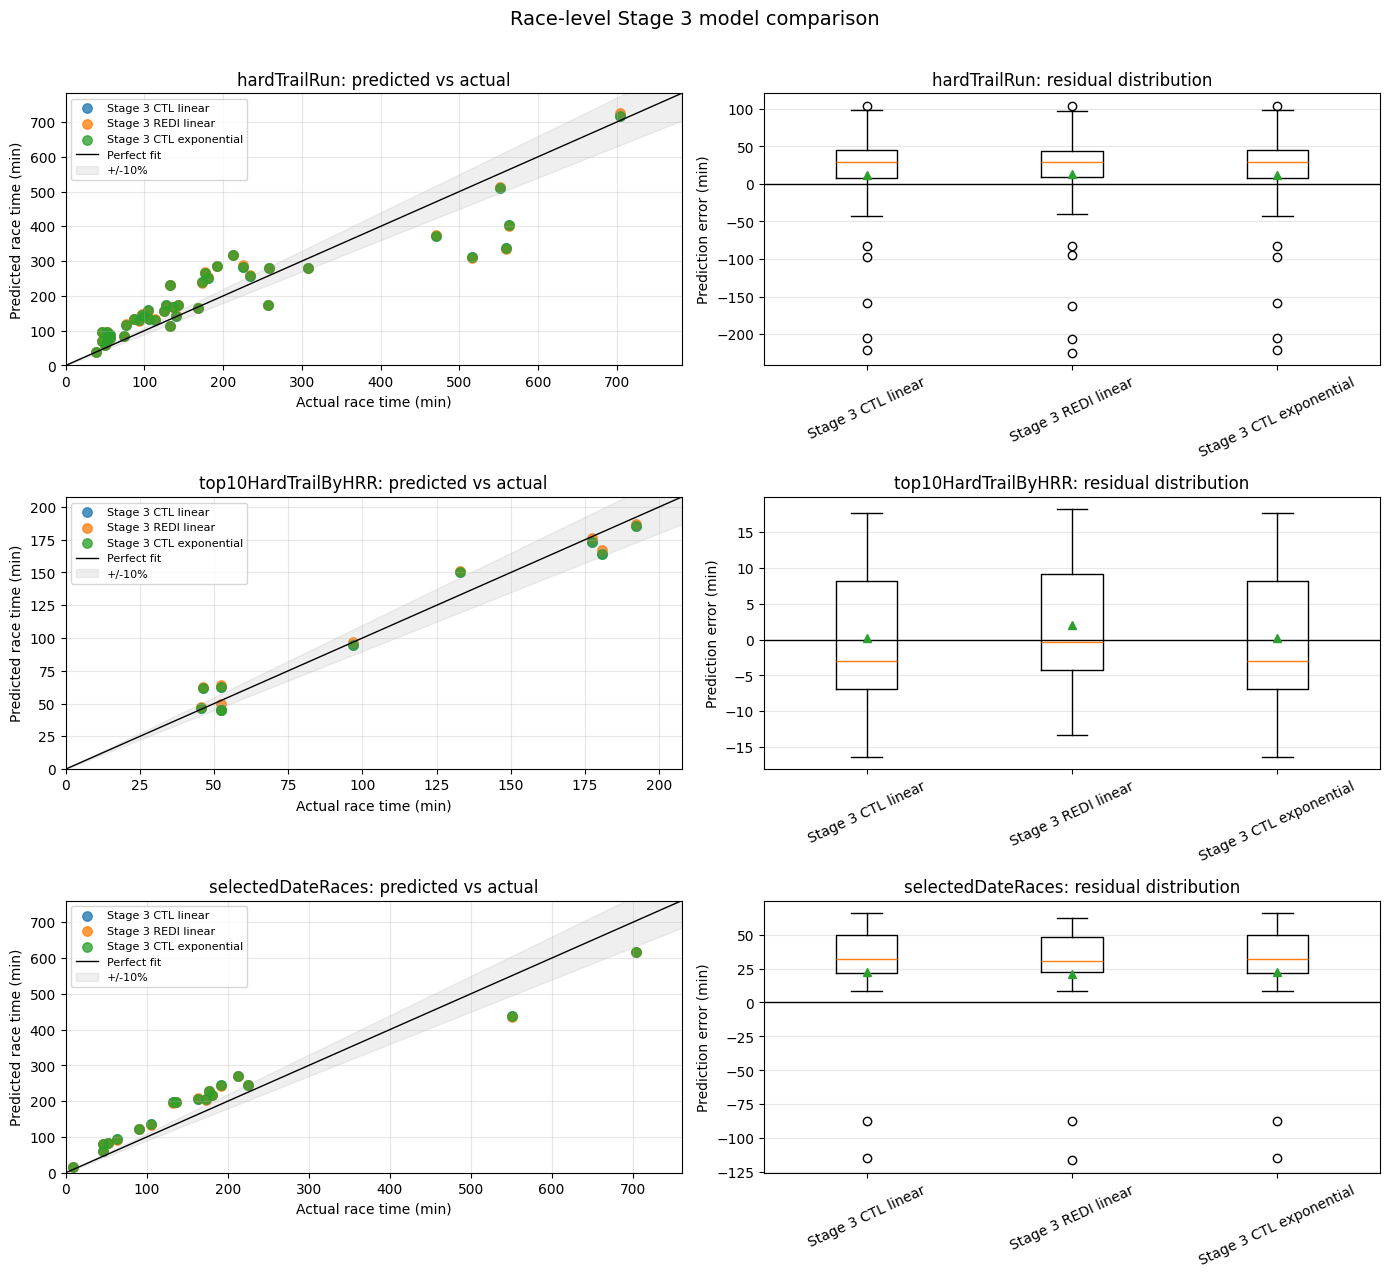

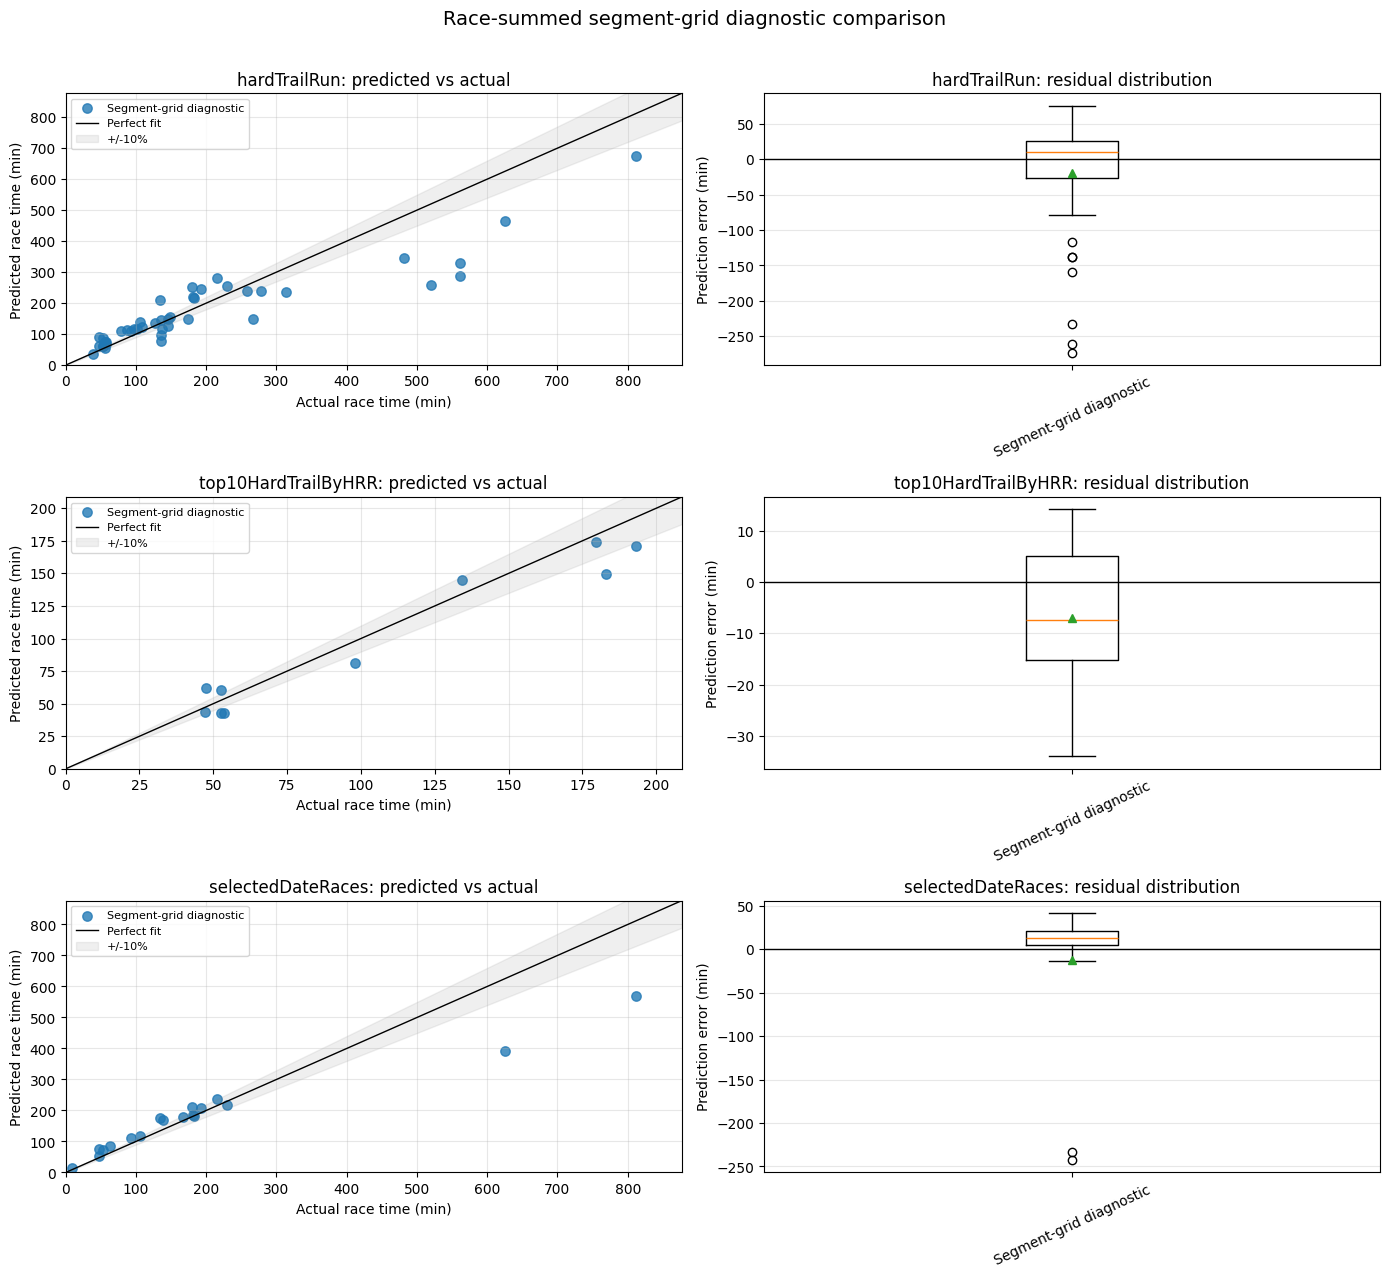

In [7]:
def plot_fit_comparison(predictions: pd.DataFrame, title: str) -> None:
    if predictions.empty:
        print(f"No predictions available for {title}")
        return

    cohorts_order = [name for name in ["hardTrailRun", "top10HardTrailByHRR", "selectedDateRaces"] if name in predictions["cohort"].unique()]
    models = predictions["model"].drop_duplicates().tolist()
    colors = dict(zip(models, plt.cm.tab10.colors[: len(models)]))

    fig, axes = plt.subplots(len(cohorts_order), 2, figsize=(14, 4.2 * len(cohorts_order)), squeeze=False)
    for row_idx, cohort_name in enumerate(cohorts_order):
        cohort_pred = predictions[predictions["cohort"].eq(cohort_name)].copy()
        if cohort_pred.empty:
            continue
        max_minutes = float(np.nanmax([cohort_pred["actualMin"].max(), cohort_pred["predictedMin"].max()]))
        limit = max(max_minutes * 1.08, 1.0)

        ax = axes[row_idx, 0]
        for model_name, model_df in cohort_pred.groupby("model", sort=False):
            ax.scatter(
                model_df["actualMin"],
                model_df["predictedMin"],
                label=model_name,
                alpha=0.78,
                s=46,
                color=colors.get(model_name),
            )
        ax.plot([0, limit], [0, limit], color="black", linewidth=1, label="Perfect fit")
        ax.fill_between([0, limit], [0, limit * 0.9], [0, limit * 1.1], color="gray", alpha=0.12, label="+/-10%")
        ax.set_xlim(0, limit)
        ax.set_ylim(0, limit)
        ax.set_xlabel("Actual race time (min)")
        ax.set_ylabel("Predicted race time (min)")
        ax.set_title(f"{cohort_name}: predicted vs actual")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

        ax = axes[row_idx, 1]
        residual_data = [cohort_pred[cohort_pred["model"].eq(model)]["errorMin"].dropna().to_numpy() for model in models]
        ax.boxplot(residual_data, tick_labels=models, showmeans=True)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_ylabel("Prediction error (min)")
        ax.set_title(f"{cohort_name}: residual distribution")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_fit_comparison(stage3_predictions, "Race-level Stage 3 model comparison")
plot_fit_comparison(segment_fit_predictions, "Race-summed segment-grid diagnostic comparison")


## Mu and Segment Diagnostics

The paper itself reports `mu = 0` in-sample while LOO folds often select negative `mu`. The checks below verify the formula sign and inspect whether the in-sample objective hides fold-specific fatigue.

,progress,f_pad_mu_0,f_pad_mu_minus_0_2,time_multiplier_vs_mu_0
0,0.0,1.0,1.0,1.000000
1,0.5,1.0,0.9,1.111111
2,1.0,1.0,0.8,1.250000


,cohort,folds,medianAlpha,medianMu,minMu,maxMu,maeMin
0,hardTrailRun,45,0.42,-0.04,-0.06,0.0,52.333406
1,selectedDateRaces,18,0.48,0.00,-0.02,0.0,49.254350
2,top10HardTrailByHRR,10,0.64,-0.02,-0.02,0.0,9.812309


,cohort,fixedAlpha,mu,r2,maeSec,mapePct,biasSec
0,hardTrailRun,0.42,-0.50,0.619567,5177.929085,68.132171,4340.118913
1,hardTrailRun,0.42,-0.48,0.644701,5007.522915,65.893657,4110.773110
2,hardTrailRun,0.42,-0.46,0.667149,4844.896313,63.754118,3891.634756
3,hardTrailRun,0.42,-0.44,0.687199,4689.441746,61.705971,3681.919563
4,hardTrailRun,0.42,-0.42,0.705104,4555.303332,59.794509,3480.928163
...,...,...,...,...,...,...,...
47,top10HardTrailByHRR,0.64,-0.08,0.965796,486.323917,11.347754,186.967319
48,top10HardTrailByHRR,0.64,-0.06,0.967492,483.116582,11.132568,126.149222
49,top10HardTrailByHRR,0.64,-0.04,0.968358,503.754734,11.181761,66.906347
50,top10HardTrailByHRR,0.64,-0.02,0.968459,523.896000,11.230251,9.169138


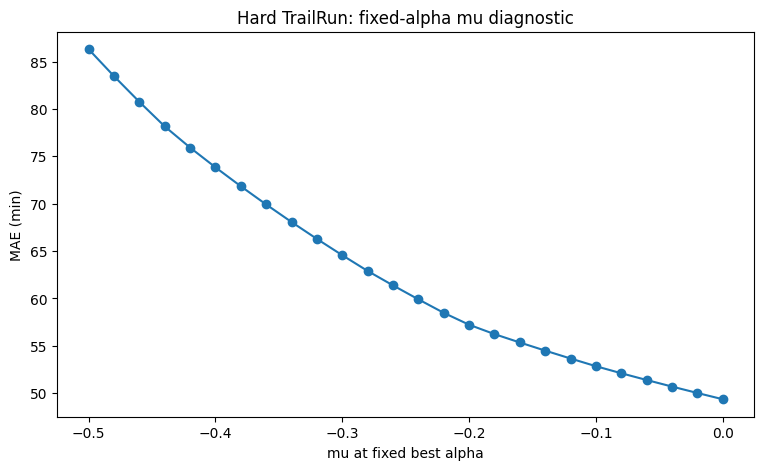

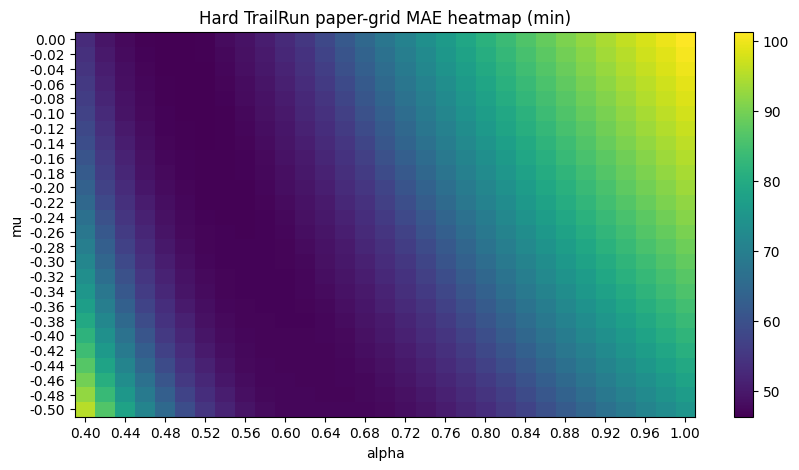

In [8]:
diagnostic_rows = []
for progress in [0.0, 0.5, 1.0]:
    neutral = tpm.linear_decay_factor(progress, 0.0)
    decayed = tpm.linear_decay_factor(progress, -0.2)
    diagnostic_rows.append(
        {
            "progress": progress,
            "f_pad_mu_0": neutral,
            "f_pad_mu_minus_0_2": decayed,
            "time_multiplier_vs_mu_0": neutral / decayed,
        }
    )
display(pd.DataFrame(diagnostic_rows))

if not loo_results.empty:
    display(
        loo_results.groupby("cohort")
        .agg(
            folds=("activityId", "count"),
            medianAlpha=("alpha", "median"),
            medianMu=("mu", "median"),
            minMu=("mu", "min"),
            maxMu=("mu", "max"),
            maeMin=("errorSec", lambda x: np.mean(np.abs(x)) / 60.0),
        )
        .reset_index()
    )

if not mu_curves.empty:
    display(mu_curves.sort_values(["cohort", "mu"]))
    hard_curve = mu_curves[mu_curves["cohort"].eq("hardTrailRun")]
    if not hard_curve.empty:
        fig, ax = plt.subplots()
        ax.plot(hard_curve["mu"], hard_curve["maeSec"] / 60.0, marker="o")
        ax.set_xlabel("mu at fixed best alpha")
        ax.set_ylabel("MAE (min)")
        ax.set_title("Hard TrailRun: fixed-alpha mu diagnostic")
        plt.show()

hard_grid = grid_by_cohort.get("hardTrailRun")
if hard_grid is not None and not hard_grid.empty:
    heat = hard_grid.pivot(index="mu", columns="alpha", values="maeSec") / 60.0
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(heat.values, aspect="auto", origin="lower")
    ax.set_xticks(range(len(heat.columns))[::2], [f"{v:.2f}" for v in heat.columns[::2]])
    ax.set_yticks(range(len(heat.index)), [f"{v:.2f}" for v in heat.index])
    ax.set_xlabel("alpha")
    ax.set_ylabel("mu")
    ax.set_title("Hard TrailRun paper-grid MAE heatmap (min)")
    fig.colorbar(im, ax=ax)
    plt.show()


## Interpretation

The closest paper replication is the Stage 3 race-level grid with CTL readiness. If `mu = 0` remains optimal in-sample, interpret it as an aggregate-cohort optimum, not proof that pacing decay is absent. The LOO `mu` distribution and fixed-alpha curves are the primary diagnostics.

'Correlation (error vs HRR): 0.333'

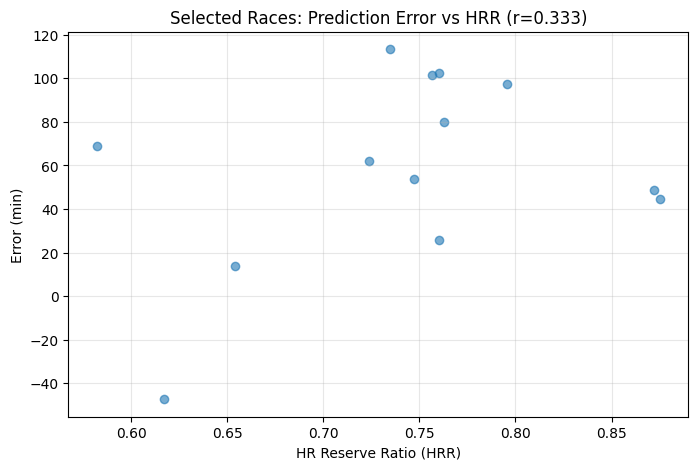

,activityId,hrReserveRatio,errorSec,actualTimeSec,predictedTimeSec
6,15329205386,0.582000,4148.265713,10390.0,14538.265713
2,14953411411,0.617333,-2836.135720,33087.0,30250.864280
7,15563904138,0.654000,831.375709,42256.0,43087.375709
12,18160385145,0.724000,3725.876088,13509.0,17234.876088
11,17481444994,0.734667,6798.710326,12779.0,19577.710326
4,15224440864,0.747333,3224.726511,6297.0,9521.726511
5,15250276952,0.756667,6087.206575,7979.0,14066.206575
1,14893241615,0.760000,1537.771839,2746.0,4283.771839
3,15087396899,0.760000,6139.904885,11532.0,17671.904885
0,14300194854,0.762667,4799.967331,10836.0,15635.967331


In [9]:
# Correlation analysis: error vs HRR in selected date races
if not loo_results.empty and not selected_activity_df.empty:
    loo_selected = loo_results[loo_results["cohort"].eq("hardTrailRun")].copy()
    if not loo_selected.empty:
        loo_selected["activityId"] = loo_selected["activityId"].astype(str)
        selected_ids = selected_activity_df["activityId"].astype(str).tolist()
        loo_selected = loo_selected[loo_selected["activityId"].isin(selected_ids)]
        
        merged = loo_selected.merge(
            selected_activity_df[["activityId", "hrReserveRatio"]].astype({"activityId": str}),
            on="activityId",
            how="left"
        )
        
        if not merged.empty and merged["hrReserveRatio"].notna().sum() > 1:
            correlation = merged["errorSec"].corr(merged["hrReserveRatio"])
            display(f"Correlation (error vs HRR): {correlation:.3f}")
            
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.scatter(merged["hrReserveRatio"], merged["errorSec"] / 60.0, alpha=0.6)
            ax.set_xlabel("HR Reserve Ratio (HRR)")
            ax.set_ylabel("Error (min)")
            ax.set_title(f"Selected Races: Prediction Error vs HRR (r={correlation:.3f})")
            ax.grid(True, alpha=0.3)
            plt.show()
            
            display(merged[["activityId", "hrReserveRatio", "errorSec", "actualTimeSec", "predictedTimeSec"]].sort_values("hrReserveRatio"))
        else:
            print("Insufficient data for correlation analysis in selected races LOO results")
    else:
        print("No LOO results available for selectedDateRaces cohort")
else:
    print("LOO results or selected_activity_df not available")